# Autotuning an MPC controller with **qpax**

This notebook shows how to **learn an MPC controller from demonstrations** by
backpropagating through a differentiable QP layer ([qpax](https://github.com/qpax-solver/qpax)). To achieve this, it follows these three steps:

1. **Generate demonstrations** — closed-loop rollouts of a "true" MPC with
   known dynamics, cost and control bound, perturbed by additive process
   noise on the plant.
2. **Learn from the demonstrations** — fit a `LearnedMPC` that is given the
   true dynamics matrices $A$, $B$ and the true control bound
   $u_\text{max}$, and only learns the cost matrices $Q$, $R$ by
   minimising the mean-squared control error against the demonstrated
   actions. Gradients flow through the QP via `qpax.solve_qp_primal`.
3. **Visualise** — training loss, side-by-side trajectory / control
   comparison (true vs. learned), and an animated receding-horizon GIF of
   the learned controller.

The user can adjust **precision**, **qpax backend**, **target $\kappa$**, and
**solver tolerance** in the first code cell.


## Configuration


In [1]:
# === User-tunable knobs ======================================================
PRECISION    = 'f64'   # 'f32' or 'f64'
BACKEND      = 'i'     # qpax backend: 'i' (implicit) or 'e' (explicit)
TARGET_KAPPA = 1e-4    # qpax relaxation kappa (used for differentiation)
SOLVER_TOL   = 1e-8    # qpax IPM convergence tolerance
MAX_ITER     = 30      # qpax max IPM iterations
# =============================================================================

import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")   # CPU is fast enough here

from functools import partial
from pathlib import Path
import time, io

import numpy as np
import jax
if PRECISION == 'f64':
    jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.scipy.linalg as jsl
import equinox as eqx
import optax
import qpax

import matplotlib.pyplot as plt
from PIL import Image

DTYPE = jnp.float64 if PRECISION == 'f64' else jnp.float32
qpax_solve = partial(
    qpax.solve_qp_primal,
    backend=BACKEND,
    solver_tol=SOLVER_TOL,
    target_kappa=TARGET_KAPPA,
    max_iter=MAX_ITER,
)

ASSETS = Path('./assets'); ASSETS.mkdir(exist_ok=True)
print(f"Config -> precision={PRECISION}, backend={BACKEND}, "
      f"target_kappa={TARGET_KAPPA}, solver_tol={SOLVER_TOL}")


Config -> precision=f64, backend=i, target_kappa=0.0001, solver_tol=1e-08


## System: 2D double-integrator

State $\mathbf{x} = [p_x, p_y, v_x, v_y]^\top$ (position + velocity),
control $\mathbf{u} = [a_x, a_y]^\top$ (acceleration), discrete dynamics
$\mathbf{x}_{k+1} = A \mathbf{x}_k + B \mathbf{u}_k$. The **true** parameters
below are what the demonstrator uses, and in this notebook we assume the
learner knows those same dynamics and actuator limits exactly.

We also fix a **velocity bound** $|v| \le v_\text{max}$ as a state constraint
(the same for true and learned controllers — it is not part of what we
"autotune").


In [2]:
nx, nu, dt = 4, 2, 0.1

A_true = jnp.array([
    [1, 0, dt, 0 ],
    [0, 1, 0,  dt],
    [0, 0, 1,  0 ],
    [0, 0, 0,  1 ],
], dtype=DTYPE)
B_true = jnp.array([
    [0.5 * dt**2, 0           ],
    [0,           0.5 * dt**2 ],
    [dt,          0           ],
    [0,           dt          ],
], dtype=DTYPE)

u_max_true = jnp.asarray(2.0, dtype=DTYPE)
Q_true     = jnp.diag(jnp.array([10.0, 10.0, 1.0, 1.0], dtype=DTYPE))
R_true     = jnp.diag(jnp.array([0.1, 0.1], dtype=DTYPE))
v_max      = 3.0   # state constraint, fixed (not learned)
PERIOD     = 120

# Assumed-known quantities for the learner.
A_known = A_true
B_known = B_true
u_max_known = u_max_true

def figure_eight_ref(t_idx, scale=3.5, period=PERIOD):
    """Reference state on a figure-eight at simulation step `t_idx`."""
    theta = 2.0 * jnp.pi * t_idx / period
    px = scale * jnp.sin(theta)
    py = scale * jnp.sin(theta) * jnp.cos(theta)
    omega = 2.0 * jnp.pi / (period * dt)
    vx = scale * jnp.cos(theta) * omega
    vy = scale * jnp.cos(2 * theta) * omega
    return jnp.stack([px, py, vx, vy]).astype(DTYPE)


## MPC as a QP — assembly

For horizon $N$, decision variable
$z = [\mathbf{x}_0, \mathbf{u}_0, \mathbf{x}_1, \mathbf{u}_1, \ldots, \mathbf{x}_{N-1}, \mathbf{u}_{N-1}, \mathbf{x}_N]$,
the MPC problem is

$$
\min_z \tfrac{1}{2} z^\top P z + q^\top z
\quad \text{s.t.}\quad
A_{\mathrm{eq}} z = b_{\mathrm{eq}},\quad G z \le h
$$

with $P = \mathrm{blkdiag}(2Q, 2R, \ldots, 2Q, 2R, 2Q_f)$,
$q$ encoding the tracking term $-2 Q \mathbf{x}^\mathrm{ref}_k$,
$A_{\mathrm{eq}}$ stacking the dynamics rows and the initial-state row,
and $G, h$ encoding $|u_k| \le u_\text{max}$ and $|v_k| \le v_\text{max}$.

The assembly below stays generic in $(Q, R, A, B, u_\text{max})$, but in
this notebook we only differentiate the QP solution with respect to the
cost terms $Q$ and $R$.


In [3]:
def assemble_mpc_qp(Q, R, A_dyn, B_dyn, u_max, x0, x_refs, N):
    """Return (P, q, A_eq, b_eq, G, h) for the MPC QP in qpax form."""
    Q_f = 10.0 * Q
    n_vars = (N + 1) * nx + N * nu

    # Cost
    P_blocks = []
    for _ in range(N):
        P_blocks += [2.0 * Q, 2.0 * R]
    P_blocks.append(2.0 * Q_f)
    P = jsl.block_diag(*P_blocks)

    q_parts = []
    for t in range(N):
        q_parts.append(-2.0 * Q @ x_refs[t])
        q_parts.append(jnp.zeros(nu, dtype=DTYPE))
    q_parts.append(-2.0 * Q_f @ x_refs[N])
    q = jnp.concatenate(q_parts)

    # Equality: dynamics A x_t + B u_t - x_{t+1} = 0, and x_0 = x0
    I_x = jnp.eye(nx, dtype=DTYPE)
    eq_rows = []
    for t in range(N):
        x_idx = t * (nx + nu)
        u_idx = x_idx + nx
        x_next = (t + 1) * (nx + nu) if t + 1 < N else N * (nx + nu)
        row = jnp.zeros((nx, n_vars), dtype=DTYPE)
        row = row.at[:, x_idx:x_idx+nx].set(A_dyn)
        row = row.at[:, u_idx:u_idx+nu].set(B_dyn)
        row = row.at[:, x_next:x_next+nx].set(-I_x)
        eq_rows.append(row)
    eq_rows.append(jnp.zeros((nx, n_vars), dtype=DTYPE).at[:, 0:nx].set(I_x))
    A_eq = jnp.concatenate(eq_rows, axis=0)
    b_eq = jnp.concatenate([jnp.zeros(N * nx, dtype=DTYPE), x0])

    # Inequality: input and velocity bounds
    I_u, I_v = jnp.eye(nu, dtype=DTYPE), jnp.eye(2, dtype=DTYPE)
    ineq_rows, ineq_h = [], []
    for t in range(N):
        u_idx = t * (nx + nu) + nx
        ineq_rows.append(jnp.zeros((nu, n_vars), DTYPE).at[:, u_idx:u_idx+nu].set( I_u))
        ineq_h.append(u_max * jnp.ones(nu, DTYPE))
        ineq_rows.append(jnp.zeros((nu, n_vars), DTYPE).at[:, u_idx:u_idx+nu].set(-I_u))
        ineq_h.append(u_max * jnp.ones(nu, DTYPE))
    for t in range(N + 1):
        x_idx = t * (nx + nu) if t < N else N * (nx + nu)
        v_idx = x_idx + 2
        ineq_rows.append(jnp.zeros((2, n_vars), DTYPE).at[:, v_idx:v_idx+2].set( I_v))
        ineq_h.append(v_max * jnp.ones(2, DTYPE))
        ineq_rows.append(jnp.zeros((2, n_vars), DTYPE).at[:, v_idx:v_idx+2].set(-I_v))
        ineq_h.append(v_max * jnp.ones(2, DTYPE))
    G = jnp.concatenate(ineq_rows, axis=0)
    h = jnp.concatenate(ineq_h)
    return P, q, A_eq, b_eq, G, h


def mpc_solution(Q, R, A_dyn, B_dyn, u_max, x0, x_refs, N):
    """Solve the MPC QP, return the full primal vector z."""
    P, q, A_eq, b_eq, G, h = assemble_mpc_qp(Q, R, A_dyn, B_dyn, u_max, x0, x_refs, N)
    return qpax_solve(P, q, A_eq, b_eq, G, h)


def first_u(z):
    """Extract u_0 from primal solution z."""
    return z[nx:nx + nu]


def extract_states(z, N):
    """Extract state trajectory (N+1, nx) from primal solution z."""
    return jnp.stack(
        [z[t * (nx + nu) : t * (nx + nu) + nx] for t in range(N)]
        + [z[N * (nx + nu) : N * (nx + nu) + nx]]
    )

# Smoke test: from [3, 3, 0, 0] with a zero reference, controls should saturate.
z_test = mpc_solution(Q_true, R_true, A_true, B_true, u_max_true,
                      jnp.array([3.0, 3.0, 0.0, 0.0], dtype=DTYPE),
                      jnp.zeros((11, nx), dtype=DTYPE), N=10)
print(f"smoke test u_0 = {first_u(z_test)}  (expected: saturated near -2)")


smoke test u_0 = [-2. -2.]  (expected: saturated near -2)


---

## 1. Generate demonstrations

The demonstrator solves the **true** MPC ($Q_{\text{true}}, R_{\text{true}},
A_{\text{true}}, B_{\text{true}}, u_{\max,\text{true}}$) at every step with
horizon $N_{\text{expert}}$, applies the first control, and steps the plant
with additive Gaussian noise $w_k \sim \mathcal{N}(0, \sigma^2 I)$:

$$\mathbf{x}_{k+1} = A_{\text{true}} \mathbf{x}_k + B_{\text{true}} \mathbf{u}_k + w_k.$$

We collect `N_TRAJ` short rollouts of length `N_STEPS` each from varied
initial conditions sampled around the figure-eight, yielding a set of
$(\mathbf{x}_k, \mathbf{u}_k, t_k)$ tuples — the training data.


In [4]:
N_EXPERT  = 15
N_TRAJ    = 16
N_STEPS   = 40
NOISE_STD = 0.02

expert_first_u = jax.jit(lambda x0, x_refs:
    first_u(mpc_solution(Q_true, R_true, A_true, B_true, u_max_true,
                         x0, x_refs, N_EXPERT))
)

def rollout(x0, n_steps, t0, noise_std, key):
    """Closed-loop rollout of the true MPC with additive process noise."""
    states   = np.zeros((n_steps + 1, nx)); states[0] = np.asarray(x0)
    controls = np.zeros((n_steps, nu))
    A_np, B_np = np.asarray(A_true), np.asarray(B_true)
    for k in range(n_steps):
        refs = jnp.stack([figure_eight_ref(t0 + k + j) for j in range(N_EXPERT + 1)])
        u = np.asarray(expert_first_u(jnp.asarray(states[k], DTYPE), refs))
        controls[k] = u
        key, sub = jax.random.split(key)
        w = noise_std * np.asarray(jax.random.normal(sub, (nx,)))
        states[k + 1] = A_np @ states[k] + B_np @ u + w
    return states, controls

rng = np.random.default_rng(0)
demo_states_list, demo_controls_list, demo_t0_list = [], [], []
print(f"Generating {N_TRAJ} demonstration trajectories...")
for i in range(N_TRAJ):
    t0_i = int(rng.integers(0, PERIOD))
    x0_i = np.asarray(figure_eight_ref(t0_i)) + 0.5 * rng.standard_normal(nx)
    states_i, controls_i = rollout(x0_i, N_STEPS, t0_i, NOISE_STD,
                                   jax.random.PRNGKey(100 + i))
    demo_states_list.append(states_i[:N_STEPS])
    demo_controls_list.append(controls_i)
    demo_t0_list.append(np.arange(N_STEPS) + t0_i)
demo_states     = np.concatenate(demo_states_list, axis=0).astype(np.float64)
demo_controls   = np.concatenate(demo_controls_list, axis=0).astype(np.float64)
demo_t0_indices = np.concatenate(demo_t0_list, axis=0).astype(np.int32)
print(f"Collected {demo_states.shape[0]} (state, control) demo pairs.")


Generating 16 demonstration trajectories...
Collected 640 (state, control) demo pairs.


---

## 2. Learn from the demonstrations

We define a `LearnedMPC` module whose **only learnable quantities** are the
cost matrices:

- **Known model**: the learner is given $A_{\text{true}}$, $B_{\text{true}}$
  and $u_{\max,\text{true}}$.
- **Cost**: $Q$ and $R$ are parameterized via Cholesky factors $L_Q, L_R$
  so that $Q = L_Q L_Q^\top + \varepsilon I$ and
  $R = L_R L_R^\top + \varepsilon I$ stay positive-definite by construction.

Because the learner now has the correct model, we let it use the **same
horizon as the expert** so the predicted receding-horizon plan is directly
comparable to the demonstrator's.

The training loss is the mean-squared error between the learner's predicted
first control $\hat{\mathbf{u}}_0$ and the demonstrated control
$\mathbf{u}^*$ at the same state with the same reference window:

$$
\mathcal{L}(\theta) = \frac{1}{N} \sum_{i=1}^{N}
   \bigl\| \mathrm{MPC}_\theta(\mathbf{x}_i, \mathbf{x}^\mathrm{ref}_i) - \mathbf{u}^*_i \bigr\|^2.
$$

Gradients $\nabla_\theta \mathcal{L}$ are computed by JAX through the qpax
solve, which in turn uses the implicit-function-theorem-based VJP from
`solve_qp_primal`.


In [5]:
N_LEARN    = N_EXPERT   # match the expert horizon for cleaner plan comparisons
N_EPOCHS   = 20
BATCH_SIZE = 32
LR         = 3e-2

class LearnedMPC(eqx.Module):
    L_Q: jax.Array
    L_R: jax.Array

    @property
    def Q(self): return self.L_Q @ self.L_Q.T + 1e-3 * jnp.eye(nx, dtype=DTYPE)
    @property
    def R(self): return self.L_R @ self.L_R.T + 1e-3 * jnp.eye(nu, dtype=DTYPE)

    def solve(self, x0, x_refs):
        return mpc_solution(self.Q, self.R, A_known, B_known, u_max_known,
                            x0, x_refs, N_LEARN)

    def __call__(self, x0, x_refs):
        return first_u(self.solve(x0, x_refs))


# Initialize only the cost away from the truth so the recovered weights are visible.
Q0 = np.diag([4.0, 4.0, 3.0, 3.0])   # true: diag(10, 10, 1, 1)
R0 = np.diag([0.8, 0.8])             # true: diag(0.1, 0.1)

def chol(M): return np.linalg.cholesky(M + 1e-6 * np.eye(M.shape[0]))

model = LearnedMPC(
    L_Q=jnp.asarray(chol(Q0), dtype=DTYPE),
    L_R=jnp.asarray(chol(R0), dtype=DTYPE),
)

# Pre-compute the learner-horizon reference window per demo sample.
demo_refs = np.zeros((len(demo_states), N_LEARN + 1, nx))
for i, t0_i in enumerate(demo_t0_indices):
    for k in range(N_LEARN + 1):
        demo_refs[i, k] = np.asarray(figure_eight_ref(int(t0_i) + k))
demo_states_j   = jnp.asarray(demo_states,   dtype=DTYPE)
demo_controls_j = jnp.asarray(demo_controls, dtype=DTYPE)
demo_refs_j     = jnp.asarray(demo_refs,     dtype=DTYPE)

n = len(demo_states_j)
schedule  = optax.cosine_decay_schedule(LR, decay_steps=N_EPOCHS * (n // BATCH_SIZE))
optimizer = optax.adam(schedule)
opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

def loss_fn(model, x_b, refs_b, u_b):
    u_pred = jax.vmap(model)(x_b, refs_b)
    return jnp.mean((u_pred - u_b) ** 2)

@eqx.filter_jit
def train_step(model, opt_state, x_b, refs_b, u_b):
    loss, grads = eqx.filter_value_and_grad(loss_fn)(model, x_b, refs_b, u_b)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    return eqx.apply_updates(model, updates), opt_state, loss

def cost_signature(Q, R):
    diag_weights = jnp.concatenate([jnp.diag(Q), jnp.diag(R)])
    return diag_weights / jnp.sum(diag_weights)

losses = []
rng_train = np.random.RandomState(0)
print(f"Training for {N_EPOCHS} epochs, batch size {BATCH_SIZE} ...")
for epoch in range(N_EPOCHS):
    t0 = time.perf_counter()
    perm = rng_train.permutation(n)
    epoch_loss, nb = 0.0, 0
    for start in range(0, n - BATCH_SIZE + 1, BATCH_SIZE):
        idx = perm[start:start + BATCH_SIZE]
        model, opt_state, loss = train_step(
            model, opt_state,
            demo_states_j[idx], demo_refs_j[idx], demo_controls_j[idx],
        )
        epoch_loss += float(loss); nb += 1
    losses.append(epoch_loss / nb)
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"  epoch {epoch+1:3d}/{N_EPOCHS}: loss = {losses[-1]:.4e}  "
              f"({time.perf_counter()-t0:.1f}s)")

print(f"\nFinal training loss: {losses[-1]:.4e}")
print("Normalized cost signature [Q_diag, R_diag]:")
print("  true   =", np.round(np.asarray(cost_signature(Q_true, R_true)), 3))
print("  learned=", np.round(np.asarray(cost_signature(model.Q, model.R)), 3))


Training for 20 epochs, batch size 32 ...
  epoch   1/20: loss = 1.3349e-01  (15.2s)
  epoch  10/20: loss = 2.1049e-05  (14.3s)
  epoch  20/20: loss = 1.0176e-05  (16.8s)

Final training loss: 1.0176e-05
Normalized cost signature [Q_diag, R_diag]:
  true   = [0.45  0.45  0.045 0.045 0.005 0.005]
  learned= [0.426 0.474 0.043 0.048 0.004 0.005]


---

## 3. Visualisation

### 3a. Training loss


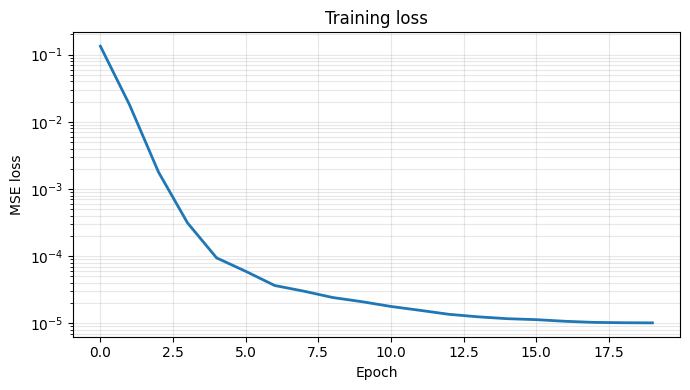

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(losses, lw=2, color='C0')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE loss')
ax.set_title('Training loss')
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
fig.savefig(ASSETS / 'loss.png', dpi=120, facecolor='white')
plt.show()


### 3b. True vs. learned MPC — trajectory and control comparison

Both controllers are deployed on the **true** plant (so this is a fair test:
the learned MPC is acting in the environment it was trained to imitate).
Solid lines = true MPC, dashed = learned MPC; the horizontal red lines show
the shared, known control bound.


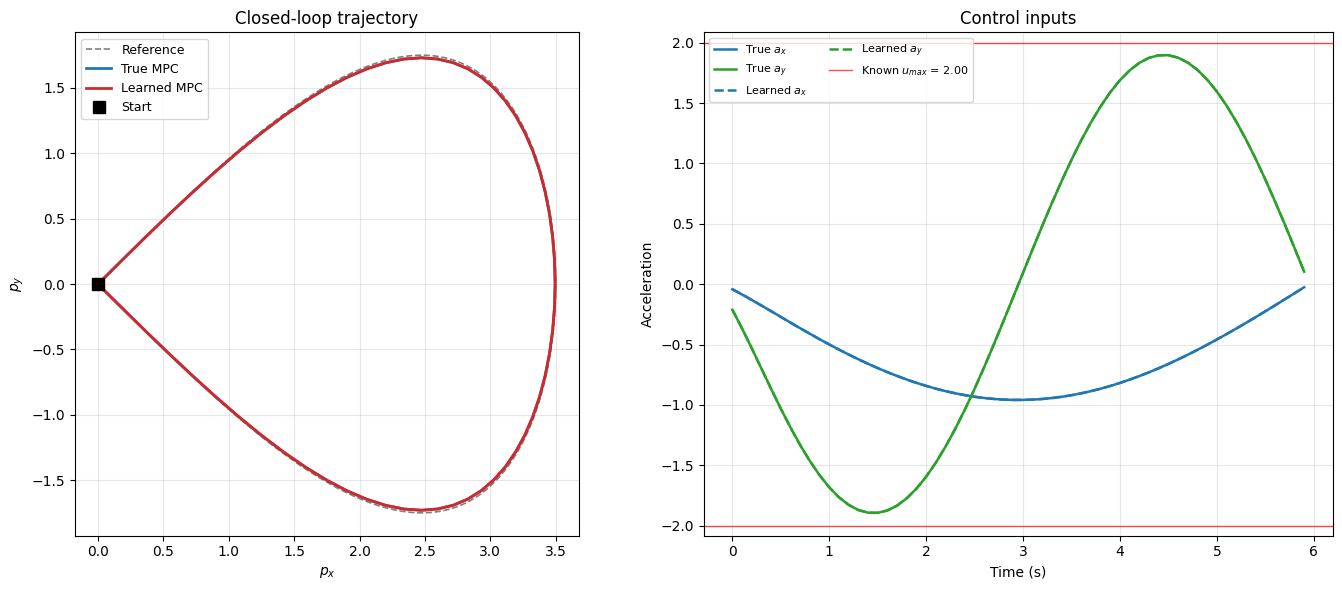

In [7]:
def closed_loop(Q, R, A_plan, B_plan, u_max, x0, n_steps, t0, N, noise_std=0.0, seed=0):
    """Roll out a controller. The plant always uses the true dynamics."""
    A_plant, B_plant = np.asarray(A_true), np.asarray(B_true)
    states = np.zeros((n_steps + 1, nx)); states[0] = np.asarray(x0)
    controls = np.zeros((n_steps, nu))
    horizons = []
    key = jax.random.PRNGKey(seed)
    solve = jax.jit(lambda x, refs:
        mpc_solution(Q, R, A_plan, B_plan, u_max, x, refs, N)
    )
    for k in range(n_steps):
        refs = jnp.stack([figure_eight_ref(t0 + k + j) for j in range(N + 1)])
        z = solve(jnp.asarray(states[k], DTYPE), refs)
        horizons.append(np.asarray(extract_states(z, N)))
        u = np.asarray(first_u(z)); controls[k] = u
        key, sub = jax.random.split(key)
        w = noise_std * np.asarray(jax.random.normal(sub, (nx,)))
        states[k + 1] = A_plant @ states[k] + B_plant @ u + w
    return states, controls, horizons


COMPARE_STEPS = 60
t0_c = 0
x0_c = np.asarray(figure_eight_ref(t0_c))

true_states,    true_ctrl,    _ = closed_loop(
    Q_true, R_true, A_true, B_true, u_max_true,
    x0_c, COMPARE_STEPS, t0_c, N_EXPERT, noise_std=0.0)
learned_states, learned_ctrl, _ = closed_loop(
    model.Q, model.R, A_known, B_known, u_max_known,
    x0_c, COMPARE_STEPS, t0_c, N_LEARN, noise_std=0.0)

ref_dense = np.stack([np.asarray(figure_eight_ref(t))
                      for t in np.linspace(0, COMPARE_STEPS, 400)])
t_sim = np.arange(COMPARE_STEPS) * dt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.plot(ref_dense[:, 0], ref_dense[:, 1], '--', color='gray', lw=1.2, label='Reference')
ax.plot(true_states[:, 0],    true_states[:, 1],    '-', color='C0', lw=2.0, label='True MPC')
ax.plot(learned_states[:, 0], learned_states[:, 1], '-', color='C3', lw=2.0, label='Learned MPC')
ax.plot(x0_c[0], x0_c[1], 's', color='black', ms=8, label='Start')
ax.set_xlabel('$p_x$'); ax.set_ylabel('$p_y$')
ax.set_title('Closed-loop trajectory'); ax.set_aspect('equal')
ax.grid(alpha=0.3); ax.legend(loc='best', fontsize=9)

ax = axes[1]
ax.plot(t_sim, true_ctrl[:, 0],    '-',  color='C0', lw=1.8, label='True $a_x$')
ax.plot(t_sim, true_ctrl[:, 1],    '-',  color='C2', lw=1.8, label='True $a_y$')
ax.plot(t_sim, learned_ctrl[:, 0], '--', color='C0', lw=1.8, label='Learned $a_x$')
ax.plot(t_sim, learned_ctrl[:, 1], '--', color='C2', lw=1.8, label='Learned $a_y$')
u_t = float(u_max_true)
ax.axhline( u_t, color='red', lw=1.0, alpha=0.7, label=f'Known $u_{{max}}$ = {u_t:.2f}')
ax.axhline(-u_t, color='red', lw=1.0, alpha=0.7)
ax.set_xlabel('Time (s)'); ax.set_ylabel('Acceleration')
ax.set_title('Control inputs'); ax.grid(alpha=0.3)
ax.legend(loc='best', fontsize=8, ncol=2)

fig.tight_layout()
fig.savefig(ASSETS / 'compare.png', dpi=120, facecolor='white')
plt.show()


### 3c. Animated receding-horizon visualization

At each step we plot the vehicle's position, a trailing actual trajectory,
the full figure-eight, the **local reference horizon** currently being fed to
the controller, and the **predicted horizon** extracted from the QP solution.
The GIF is saved to `assets/learned_mpc_anim.gif`.


Rendering 80 frames ...
Saved assets/learned_mpc_anim.gif


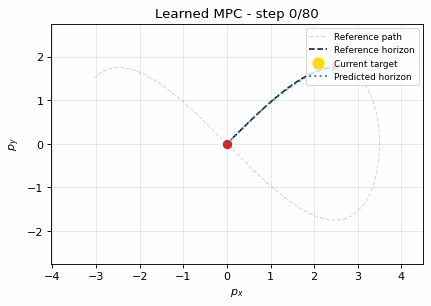

In [8]:
ANIM_STEPS = 80
anim_x0 = np.asarray(figure_eight_ref(0))
anim_states, _, anim_horizons = closed_loop(
    model.Q, model.R, A_known, B_known, u_max_known,
    anim_x0, ANIM_STEPS, 0, N_LEARN, noise_std=0.0)

ref_anim = np.stack([np.asarray(figure_eight_ref(t))
                     for t in np.linspace(0, ANIM_STEPS, 400)])
xlim = (min(anim_states[:, 0].min(), ref_anim[:, 0].min()) - 1.0,
        max(anim_states[:, 0].max(), ref_anim[:, 0].max()) + 1.0)
ylim = (min(anim_states[:, 1].min(), ref_anim[:, 1].min()) - 1.0,
        max(anim_states[:, 1].max(), ref_anim[:, 1].max()) + 1.0)

def fig_to_pil(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=80, facecolor='white', bbox_inches='tight')
    buf.seek(0)
    return Image.open(buf).copy()

print(f"Rendering {ANIM_STEPS} frames ...")
frames, trail = [], 15
for k in range(ANIM_STEPS):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(ref_anim[:, 0], ref_anim[:, 1], '--', color='gray', lw=1.0, alpha=0.35,
            label='Reference path')
    ref_now = np.asarray(figure_eight_ref(k))
    ref_window = np.stack([np.asarray(figure_eight_ref(k + j)) for j in range(N_LEARN + 1)])
    ax.plot(ref_window[:, 0], ref_window[:, 1], '--', color='black', lw=1.4, alpha=0.9,
            label='Reference horizon')
    ax.plot(ref_now[0], ref_now[1], 'o', color='gold', ms=10, alpha=0.9, label='Current target')
    ts = max(0, k - trail)
    if k > ts:
        ax.plot(anim_states[ts:k+1, 0], anim_states[ts:k+1, 1], '-', color='C3', lw=2)
    ax.plot(anim_states[k, 0], anim_states[k, 1], 'o', color='C3',
            ms=10, mec='white', mew=1.5)
    pred = anim_horizons[k]
    ax.plot(pred[:, 0], pred[:, 1], ':', color='C0', lw=1.8, alpha=0.9,
            label='Predicted horizon')
    ax.plot(pred[-1, 0], pred[-1, 1], 'x', color='C0', ms=8)
    ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_aspect('equal')
    ax.set_title(f'Learned MPC - step {k}/{ANIM_STEPS}')
    ax.set_xlabel('$p_x$'); ax.set_ylabel('$p_y$')
    ax.legend(loc='upper right', fontsize=8); ax.grid(alpha=0.3)
    frames.append(fig_to_pil(fig)); plt.close(fig)

gif_path = ASSETS / 'learned_mpc_anim.gif'
frames[0].save(gif_path, save_all=True, append_images=frames[1:],
               duration=80, loop=0, optimize=False)
print(f"Saved {gif_path}")

from IPython.display import Image as IPyImage, display
display(IPyImage(filename=str(gif_path)))
